In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [3]:
df = pd.read_excel("online_retail_II.xlsx")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(525461, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [8]:
df = df.dropna(subset=["Customer ID"])

In [9]:
df["Revenue"] = df["Quantity"] * df["Price"]
df = df[df["Price"] > 0]
df["IsReturn"] = (df["Quantity"] < 0).astype(int)
 
print("Cleaned shape:", df.shape)

Cleaned shape: (417503, 10)


In [10]:
snapshot = df["InvoiceDate"].max() + dt.timedelta(days=1)
 
customers = df.groupby("Customer ID").agg(

    Recency=("InvoiceDate", lambda x: (snapshot - x.max()).days),  # days since last buy
    Frequency=("Invoice", "nunique"),                              # number of distinct orders
    Monetary=("Revenue", "sum"),                                   # net spend (returns offset)

    FirstPurchase=("InvoiceDate", "min"),                          # for tenure
    UniqueProducts=("StockCode", "nunique"),                       # variety of items
    TotalItems=("Quantity", "sum"),                                # net items bought
    ReturnRate=("IsReturn", "mean"),                               # share of rows that are returns
)

customers["Tenure"] = (snapshot - customers["FirstPurchase"]).dt.days
customers = customers.drop(columns="FirstPurchase")
customers["AvgOrderValue"] = customers["Monetary"] / customers["Frequency"]
customers = customers[customers["Monetary"] > 0]
 
print("\nCustomer-level table:")
customers.describe().T


Customer-level table:


,count,mean,std,min,25%,50%,75%,max
Recency,4283.0,88.529302,95.716440,1.000000e+00,17.000,50.000,130.000000,374.00
Frequency,4283.0,5.454588,10.147717,1.000000e+00,1.000,3.000,6.000000,270.00
Monetary,4283.0,1971.249592,8595.611787,8.881784e-16,303.660,686.540,1683.525000,341776.73
UniqueProducts,4283.0,64.231380,86.200912,1.000000e+00,17.000,39.000,80.000000,1749.00
TotalItems,4283.0,1241.545412,6216.917216,0.000000e+00,157.000,379.000,988.000000,218090.00
ReturnRate,4283.0,0.024497,0.057464,0.000000e+00,0.000,0.000,0.023483,0.60
Tenure,4283.0,228.336213,119.618163,1.000000e+00,121.000,255.000,336.000000,374.00
AvgOrderValue,4283.0,312.246566,393.572005,4.440892e-16,152.975,234.378,356.482500,11880.84


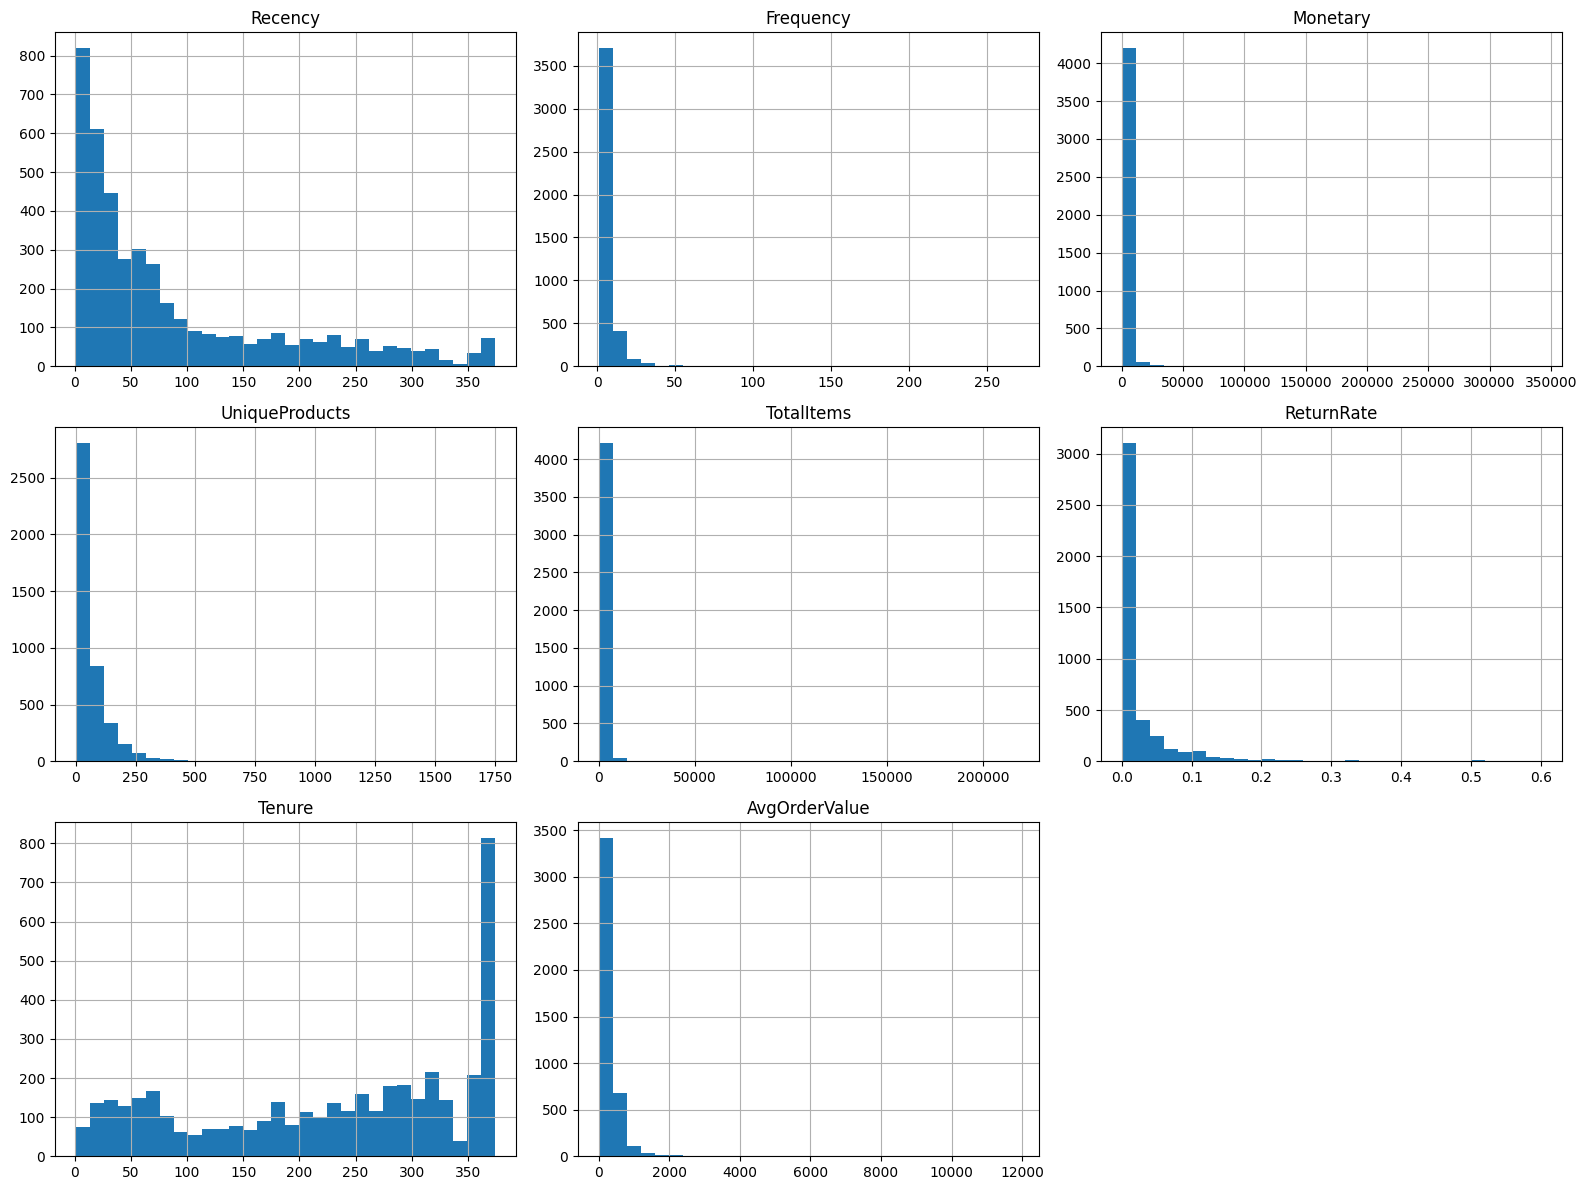

In [11]:
customers.hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

In [12]:
skewed = ["Recency", "Frequency", "Monetary", "UniqueProducts",
          "TotalItems", "AvgOrderValue", "Tenure"]
 
features = customers.copy()
for col in skewed:
    features[col] = np.log1p(features[col]) 

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [14]:
scaler = StandardScaler()
X = scaler.fit_transform(features)

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print("\nVariance explained by 2 PCs:", pca.explained_variance_ratio_.sum().round(3))


Variance explained by 2 PCs: 0.686


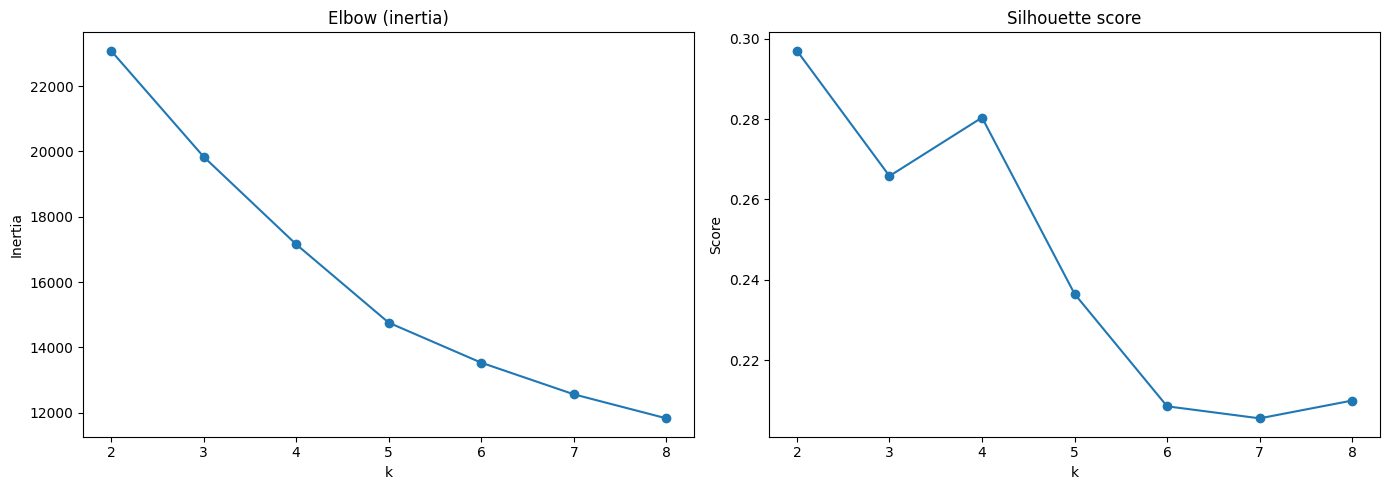


Best k by silhouette: 2 (review the elbow plot too — judgment, not just the max)


In [16]:
inertias, silhouettes, k_range = [], [], range(2, 9)
 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))
 
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(k_range), inertias, "o-"); ax[0].set_title("Elbow (inertia)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(k_range), silhouettes, "o-"); ax[1].set_title("Silhouette score")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Score")
plt.tight_layout(); plt.show()
 
best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"\nBest k by silhouette: {best_k} (review the elbow plot too — judgment, not just the max)")
 

In [17]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customers["Cluster"] = kmeans.fit_predict(X)

agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(X)
print("\nKMeans cluster sizes:")
print(customers["Cluster"].value_counts().sort_index())


KMeans cluster sizes:
Cluster
0    1943
1    2340
Name: count, dtype: int64


In [18]:
profile = customers.groupby("Cluster").agg(
    Count=("Recency", "size"),
    Recency=("Recency", "median"),
    Frequency=("Frequency", "median"),
    Monetary=("Monetary", "median"),
    AvgOrderValue=("AvgOrderValue", "median"),
    Tenure=("Tenure", "median"),
    ReturnRate=("ReturnRate", "median"),
).round(2)
 
print("\n=== SEGMENT PROFILES ===")
print(profile)
print("""
Now NAME each cluster from its profile, e.g.:
  - low Recency + high Frequency + high Monetary  -> "Champions / loyal high-value"
  - high Recency + low Frequency                  -> "Lapsed / at-risk"
  - low Monetary + low Frequency + recent         -> "New / low-value"
  - high ReturnRate                               -> "Heavy returners"
""")


=== SEGMENT PROFILES ===
         Count  Recency  Frequency  Monetary  AvgOrderValue  Tenure  \
Cluster                                                               
0         1943     23.0        7.0   1839.03         284.74   315.0   
1         2340     88.0        1.0    321.52         191.18   184.0   

         ReturnRate  
Cluster              
0              0.01  
1              0.00  

Now NAME each cluster from its profile, e.g.:
  - low Recency + high Frequency + high Monetary  -> "Champions / loyal high-value"
  - high Recency + low Frequency                  -> "Lapsed / at-risk"
  - low Monetary + low Frequency + recent         -> "New / low-value"
  - high ReturnRate                               -> "Heavy returners"



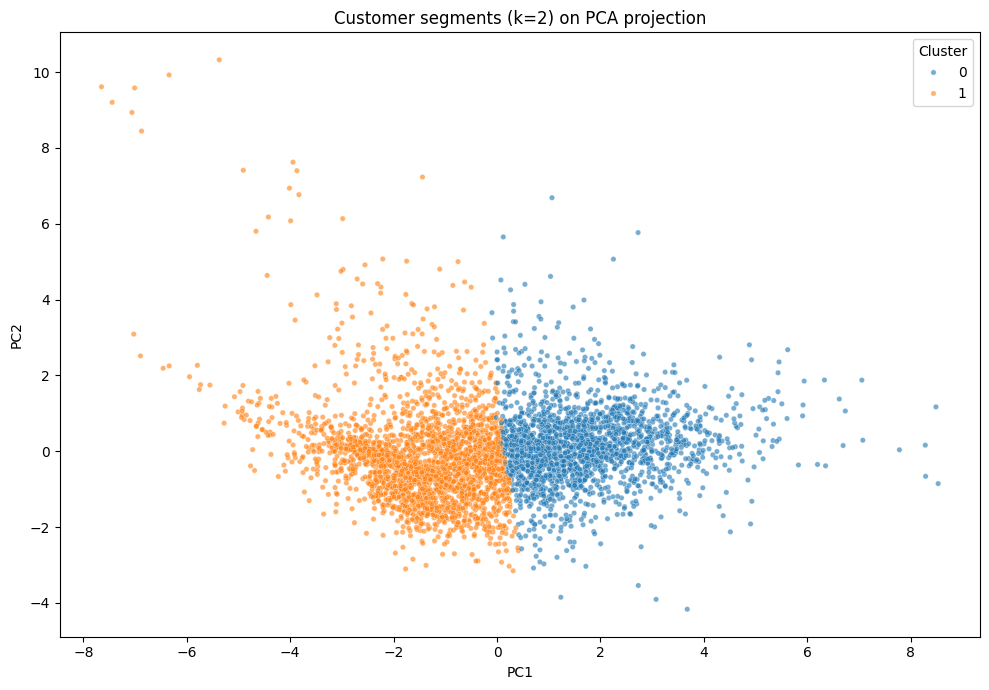


Saved customers_segmented.csv


In [19]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=customers["Cluster"], palette="tab10", s=15, alpha=0.6)
plt.title(f"Customer segments (k={best_k}) on PCA projection")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout(); plt.show()
 
# Save the labeled customers for any downstream use.
customers.to_csv("customers_segmented.csv")
print("\nSaved customers_segmented.csv")